<a href="https://colab.research.google.com/github/BREIMER606/Programaci-n-Cient-fica/blob/main/Lab1_Pct.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SCIENTIFIC COMPUTING – Lab_2

Breimer Meneses

# Context and  database description

<div style="text-align: justify;">
Indoor localization presents a fundamental challenge for applications in the industrial, logistics, and autonomous navigation sectors due to the limitations of conventional satellite technologies, such as GPS, which exhibit low accuracy in enclosed environments [1]. UWB has high temporal resolution and the ability to mitigate multipath effects [2]. However, the presence of NLOS conditions and reflections causes significant biases and errors in distance measurements [3]. Figure 1 illustrates the spatial trajectory of a drone obtained using an experimental setup with a localization system based on UWB and IMUs [7].

The choice of this database stems from my research, in which I seek to overcome the individual challenges of each sensor by using sensor data fusion techniques to integrate UWB, odometry, and IMU measurements. This improves accuracy and robustness by leveraging the advantages of each modality, for which machine learning algorithms are commonly used for data fusion [4, 5]. The recorded dataset includes synchronized measurements of the drone's three-dimensional position coordinates (x, y, z), along with IMU data such as accelerations and angular velocities, and environmental parameters such as barometric pressure. This data is divided into two main groups: the first, composed of the physical measurement variables, and the second, composed of the identifiers.

<div style="text-align: center;">
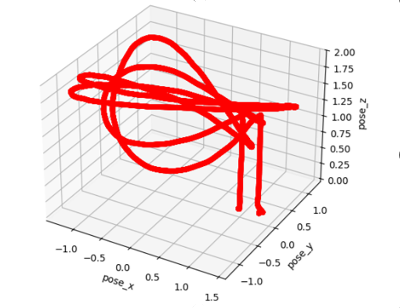

*Figure 1. 3D trajectory recorded by the drone on the (x, γ, z) axes. Source: Own elaboration, based on the file const1-trial2-tdoa2.csv [7]*



In [251]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.fft import fft
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from collections import Counter

# Advanced data handling with Pandas

Loading data frame and displaying initial data

In [252]:
# URL 
url_csv = "https://raw.githubusercontent.com/BREIMER606/Programaci-n-Cient-fica/main/Laboratorio_1/const1-trial2-tdoa2.csv"

df = pd.read_csv(url_csv)
print(f" DataFrame change with {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

 DataFrame change with 123428 rows and 27 columns.


,t_tdoa,idA,idB,tdoa_meas,t_acc,acc_x,acc_y,acc_z,t_gyro,gyro_x,...,t_baro,baro,t_pose,pose_x,pose_y,pose_z,pose_qx,pose_qy,pose_qz,pose_qw
0,0.002370,0.0,1.0,0.483252,0.000015,0.023713,0.002465,1.000307,0.000000,0.017114,...,0.017164,219.667511,0.001411,1.315,0.033,0.085,-0.004151,-0.008303,0.024908,0.999647
1,0.005162,1.0,3.0,-1.074414,0.001013,0.023955,0.002886,1.000366,0.000991,0.000684,...,0.036966,219.744049,0.005748,1.315,0.033,0.085,-0.002768,-0.006919,0.023524,0.999695
2,0.006641,3.0,4.0,1.604583,0.002038,0.024130,0.003349,1.000466,0.002022,-0.031852,...,0.056791,219.716705,0.010518,1.315,0.033,0.085,-0.002768,-0.006919,0.022140,0.999727
3,0.008731,4.0,5.0,-2.374032,0.002988,0.024223,0.003737,1.000606,0.002973,-0.060674,...,0.076612,219.771393,0.017529,1.315,0.033,0.085,-0.002768,-0.006919,0.023524,0.999695
4,0.010805,5.0,6.0,0.882052,0.003976,0.024270,0.003952,1.000732,0.003960,-0.065456,...,0.096446,219.722168,0.019996,1.315,0.033,0.085,-0.004151,-0.008303,0.026292,0.999611


<div style="text-align: justify;">
In this section, the original dataset was segmented and highlighted into subsets related to the following signals: UWB, IMU accelerometer, IMU gyroscope, and pose.

For each segment, the relevant columns were identified, and a pandas DataFrame was created to facilitate individual analysis. Using the `print_missing_info` function, the missing data in each segment was inspected, evaluating the total number of values, how many were missing, and the percentage they represented.

In [253]:
# Column lists by segment
uwb_cols = ['t_tdoa','idA','idB','tdoa_meas']
imu_cols_acc = ['acc_x','acc_y','acc_z']
imu_cols_gyro = ['gyro_x','gyro_y','gyro_z']
pose_cols = ['pose_x','pose_y','pose_z']

# DataFrames segmentados
df_uwb = df[uwb_cols]
df_imu_acc = df[imu_cols_acc]
df_imu_gyro = df[imu_cols_gyro]
df_pose = df[pose_cols]

def print_missing_info(df_segment, segment_name):
    total_values = df_segment.size
    missing_values = df_segment.isnull().sum().sum()
    missing_percent = (missing_values / total_values) * 100
    print(f"{segment_name}:")
    print(f"  Total values: {total_values}")
    print(f"  Missing values: {missing_values}")
    print(f"  Missing percentage: {missing_percent:.2f}%\n")

print_missing_info(df_uwb, "UWB")
print_missing_info(df_imu_acc, "IMU_acc")
print_missing_info(df_imu_gyro, "IMU_gyro")
print_missing_info(df_pose, "Pose")


UWB:
  Total values: 493712
  Missing values: 261504
  Missing percentage: 52.97%

IMU_acc:
  Total values: 370284
  Missing values: 0
  Missing percentage: 0.00%

IMU_gyro:
  Total values: 370284
  Missing values: 0
  Missing percentage: 0.00%

Pose:
  Total values: 370284
  Missing values: 296862
  Missing percentage: 80.17%



Data Cleaning and Preprocessing

This section handled the cleaning of the previously segmented data.  
Specifically, in the **UWB** segment, rows containing missing values ($NaN$) in the main measurement column **$tdoa\_meas$** were removed using the `dropna()` method.  
This was done due to the large amount of data and to ensure that only complete and valid data for this segment was retained, avoiding bias from arbitrary imputations.

On the other hand, in the **Pose** segment, missing values were filled using **linear interpolation** with the following expression:

```python
interpolate(method='linear', limit_direction='both')



In [254]:
# UWB: Delete rows with NaN
df_uwb_clean = df_uwb.dropna(subset=['tdoa_meas'])

# Pose: Fill NaN with linear interpolation
df_pose_clean = df_pose.interpolate(method='linear', limit_direction='both')

print("UWB clean:", df_uwb_clean.shape)
print("Pose clean:", df_pose_clean.shape)


UWB clean: (58052, 4)
Pose clean: (123428, 3)




 Global Motion State Classification

A **classification of the global motion state** was performed based on the acceleration magnitudes measured by the IMU accelerometer along the three axes ($x$, $y$, $z$).  
First, **global percentiles** were defined for each axis: the 15th percentile as the *low threshold* ($low\_thrs$) and the 85th percentile as the *high threshold* ($high\_thrs$), calculated from the distribution of acceleration data along each axis.

Then, for each row (i.e., for each time instant), the acceleration values for each axis were evaluated and labeled into three possible states:

- **Repose** → if the value was below the low threshold.  
- **Motion** → if it exceeded the high threshold.  
- **Transition** → if it was between both thresholds.

Finally, a **global state** was assigned to each time instant by determining the most frequent category among the three axes.  
This generated a new column in the DataFrame called `$final\_global\_mobile\_state$`.  
The resulting classification allows us to count the number of samples in each category.

This procedure provides a **simple and effective method** for segmenting the dynamic behavior measured by the accelerometer into states of *rest*, *movement*, and *transition*, facilitating subsequent analyses based on physical activity detected by IMU sensors.



In [255]:
# Define global percentiles per axis
imu_cols_acc = ['acc_x','acc_y','acc_z']
low_thrs = {col: df[col].quantile(0.15) for col in imu_cols_acc}
high_thrs = {col: df[col].quantile(0.85) for col in imu_cols_acc}

def moving_state_axes(row):
    labels = []
    for col in imu_cols_acc:
        if row[col] < low_thrs[col]:
            labels.append('repose')
        elif row[col] > high_thrs[col]:
            labels.append('motion')
        else:
            labels.append('transition')
    # Assign the most frequent state among the three axes
    return max(set(labels), key=labels.count)

df['final_global_mobile_state'] = df.apply(moving_state_axes, axis=1)
print(df['final_global_mobile_state'].value_counts())

final_global_mobile_state
transition    96250
repose        18602
motion         8576
Name: count, dtype: int64


# Feature Extraction using OOP



This section implements a **module for extracting relevant features** from the IMU accelerometer dataset, both in the **time** and **frequency** domains, using the principles of **object-oriented programming (OOP)**.

A base class, **`FeatureExtractor`**, was defined to establish the general structure for feature extraction.  
Two specialized classes were derived from this base class:

- **`TimeDomainFeatures`** → Calculates classical statistical features in the time domain, such as the **mean ($\mu$)**, **standard deviation ($\sigma$)**, and **root mean square (RMS)** of the signal.

- **`FrequencyDomainFeatures`** → Transforms the signal using the **Fast Fourier Transform (FFT)** to extract frequency-domain features, specifically the **weighted average frequency** and **peak frequency** of the spectrum.

A function was then implemented to iterate over the accelerometer columns of the DataFrame (axes $x$, $y$, $z$), extracting both time- and frequency-domain features for each axis, storing and displaying the results.

This procedure provides a **quantitative summary of the dynamic behavior** of the IMU signals, characterizing their variability and spectral composition.  
The combination of these two feature domains allows a deeper understanding of the **signal properties and motion dynamics** captured by the IMU sensor.



In [ ]:
# Base class
class FeatureExtractor:
    """
    Base class for feature extraction.
    """
    def __init__(self, data):
        self.data = data  

    def extract_features(self):
        raise NotImplementedError("Implement in a subclass")

# Class for time domain features
class TimeDomainFeatures(FeatureExtractor):
    def extract_features(self):
        mean = np.mean(self.data)
        std = np.std(self.data)
        rms = np.sqrt(np.mean(np.square(self.data)))
        return {'mean': mean, 'std': std, 'rms': rms}

# Class for frequency domain features
class FrequencyDomainFeatures(FeatureExtractor):
    def extract_features(self):
        yf = fft(self.data)
        N = len(self.data)
        dt = 0.01 # sampling interval
        xf = np.linspace(0.0, 1.0/(2.0*dt), N//2)
        magnitude = 2.0 / N * np.abs(yf[0:N//2])

        mean_freq = np.sum(xf * magnitude) / np.sum(magnitude) if np.sum(magnitude) > 0 else 0
        peak_freq = xf[np.argmax(magnitude)] if len(magnitude) > 0 else 0

        return {'mean_freq': mean_freq, 'peak_freq': peak_freq}

# columns_acc
def extract_imu_acc_features(df, columns):
    feature_results = {}
    for col in columns:
        time_feats = TimeDomainFeatures(df[col]).extract_features()
        freq_feats = FrequencyDomainFeatures(df[col]).extract_features()
        feature_results[col] = {'time_domain': time_feats, 'frequency_domain': freq_feats}
    return feature_results

# Execution
imu_cols_acc = ['acc_x', 'acc_y', 'acc_z']
feature_results = extract_imu_acc_features(df, imu_cols_acc)

# Results
for col, feats in feature_results.items():
    print(f"\nFeatures of {col}:")
    print(" Temporary domain:")
    for name, val in feats['time_domain'].items():
        print(f"    {name}: {val:.4f}")
    print(" Frequency domain:")
    for name, val in feats['frequency_domain'].items():
        print(f"    {name}: {val:.4f}")



Features of acc_x:
 Temporary domain:
    mean: -0.0103
    std: 0.0188
    rms: 0.0214
 Frequency domain:
    mean_freq: 5.7684
    peak_freq: 0.0000

Features of acc_y:
 Temporary domain:
    mean: 0.0088
    std: 0.0296
    rms: 0.0309
 Frequency domain:
    mean_freq: 5.9533
    peak_freq: 0.0000

Features of acc_z:
 Temporary domain:
    mean: 1.0012
    std: 0.0235
    rms: 1.0014
 Frequency domain:
    mean_freq: 2.5881
    peak_freq: 0.0000


# Statistical Analysis and Visualization

<div style="text-align: justify;"> In this section, "violin diagram" type graphs were generated to compare the distribution of IMU accelerometer signals on axes ( X, Y, Z) according to the previously classified global motion state (rest, transition, motion). Multiple subgraphs were created, one for each axis, to simultaneously visualize the distributions by state and facilitate comparison.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3880\1845334136.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=axes[idx], x='final_global_mobile_state', y=var, data=df, palette='Set2', inner='box')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_3880\1845334136.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=axes[idx], x='final_global_mobile_state', y=var, data=df, palette='Set2', inner='box')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_3880\1845334136.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=axes[idx], x='final_gl

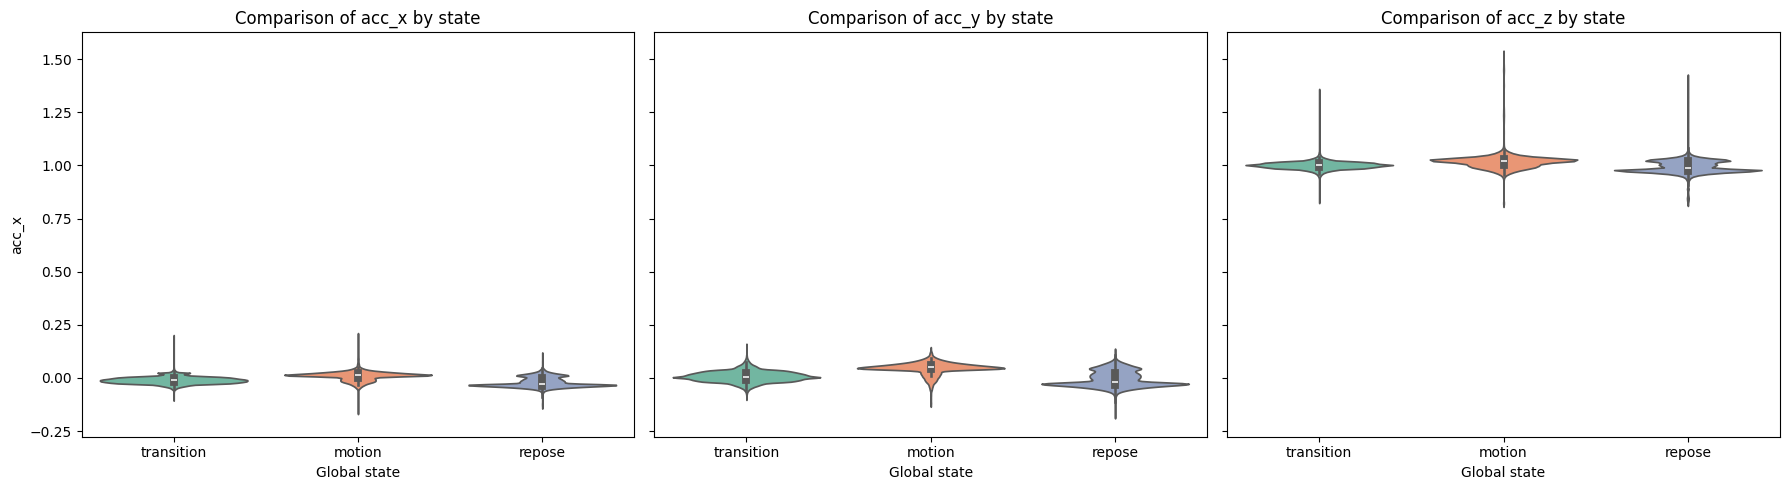

In [ ]:
fig, axes = plt.subplots(1, len(imu_cols_acc), figsize=(18, 5), sharey=True)
for idx, var in enumerate(imu_cols_acc):
    sns.violinplot(ax=axes[idx], x='final_global_mobile_state', y=var, data=df, palette='Set2', inner='box')
    axes[idx].set_title(f'Comparison of {var} by state')
    axes[idx].set_xlabel('Global state')
    axes[idx].set_ylabel(var if idx == 0 else "")

plt.tight_layout()
plt.show()

<div style="text-align: justify;"> Four analyses are presented to evaluate the separability and differences between the global motion states measured by the IMU sensors.

- Visualization with Pairplot: A Seaborn pairplot is used to visually explore the relationships between the acceleration variables on the three axes under study, color-coding each global state. This graph shows marginal distributions (kde) and bivariate dispersion for each pair of variables, helping to identify whether the states are well differentiated in the feature space.

- Fisher Index: The Fisher index is calculated for each variable, measuring the separability between classes by evaluating the relationship between between-group variance and within-group variance.

- ANOVA between states: Analysis of variance is performed for each variable to statistically determine whether there are significant differences between the means of the variables in the different motion states. The F-statistic and p-value are used to determine whether the observed differences are statistically significant.

- Calculation of distances between scaled centroids: Scaling of the acceleration variables and calculation of the centroids (averages) of each state in the scaled feature space. Then a calculation of the Euclidean distances between these centroids to quantify the geometric separation between states, which complements the separability analysis from a vectorial point of view.

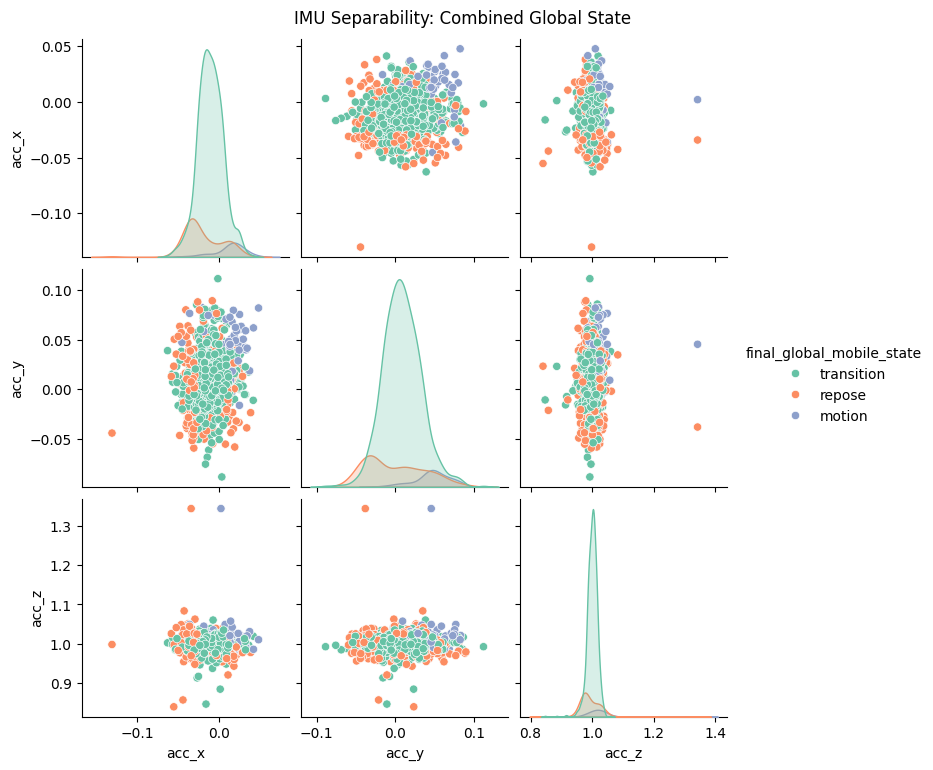


 FISHER INDEX (Combined Global Status)):
acc_x: 0.3833
acc_y: 0.5734
acc_z: 0.1222

 ANOVA (Combined Overall Status):
acc_x: F = 8499.6562, p = 0.000000
acc_y: F = 10390.5664, p = 0.000000
acc_z: F = 4109.1582, p = 0.000000
Distance transition vs motion: 1.8870
Distance transition vs repose: 0.7331
Distance motion vs repose: 2.6130


In [ ]:
# 1. Pairplot Visualization
sns.pairplot(df.sample(1000), 
             vars=['acc_x', 'acc_y', 'acc_z'], 
             hue='final_global_mobile_state', 
             palette='Set2', 
             diag_kind='kde')
plt.suptitle("IMU Separability: Combined Global State", y=1.02)
plt.show()

# 2. Fisher Index (fisher_index function)
def fisher_index(serie, labels):
    groups = [serie[labels == clase] for clase in np.unique(labels)]
    means = [np.mean(g) for g in groups]
    vars_ = [np.var(g) for g in groups]
    numerator = np.sum([(m - np.mean(serie))**2 for m in means])
    denominator = np.sum(vars_)
    return numerator / (denominator + 1e-10)

print("\n FISHER INDEX (Combined Global Status)):")
for var in imu_cols_acc:
    fisher = fisher_index(df[var], df['final_global_mobile_state'])
    print(f"{var}: {fisher:.4f}")

# 3. Between-state ANOVA
print("\n ANOVA (Combined Overall Status):")
for var in imu_cols_acc:
    grupos = [df[df['final_global_mobile_state'] == state][var].values 
              for state in df['final_global_mobile_state'].unique()]
    f_stat, p_value = f_oneway(*grupos)
    print(f"{var}: F = {f_stat:.4f}, p = {p_value:.6f}")

#4. Distances between scaled centroids
scaler = StandardScaler()
X = scaler.fit_transform(df[imu_cols_acc])
unique_states = df['final_global_mobile_state'].unique()
centroids = {state: X[df['final_global_mobile_state'] == state].mean(axis=0) for state in unique_states}

for i, state1 in enumerate(unique_states):
    for state2 in unique_states[i+1:]:
        dist = np.linalg.norm(centroids[state1] - centroids[state2])
        print(f"Distance {state1} vs {state2}: {dist:.4f}")


<div style="text-align: justify;"> This section of the notebook describes the complete training and evaluation process for a classification model based exclusively on IMU accelerometer signals.

First, the features (x) are defined as the acceleration values ​​on the three axes, and the labels (y) as the previously calculated global motion state. The dataset is then divided into training (80%) and test (20%), ensuring that the label distribution remains proportional in both partitions (stratification). The state distribution in each subset is first calculated to verify this proportion.

A Random Forest classifier is then trained with 100 trees using the training set. This model is robust and efficient for supervised classification problems with multivariate data.

Predictions were made on the test set using the trained model, and its performance was evaluated by calculating classification metrics such as accuracy, recall, F1 score, and support for each class. A classification report is also presented, and the confusion matrix is ​​visualized to examine classification successes and failures between categories.

Distribution in training:
Counter({'transition': 77000, 'repose': 14881, 'motion': 6861})

Test distribution:
Counter({'transition': 19250, 'repose': 3721, 'motion': 1715})

Classification report:
              precision    recall  f1-score   support

      motion       1.00      1.00      1.00      1715
      repose       1.00      1.00      1.00      3721
  transition       1.00      1.00      1.00     19250

    accuracy                           1.00     24686
   macro avg       1.00      1.00      1.00     24686
weighted avg       1.00      1.00      1.00     24686



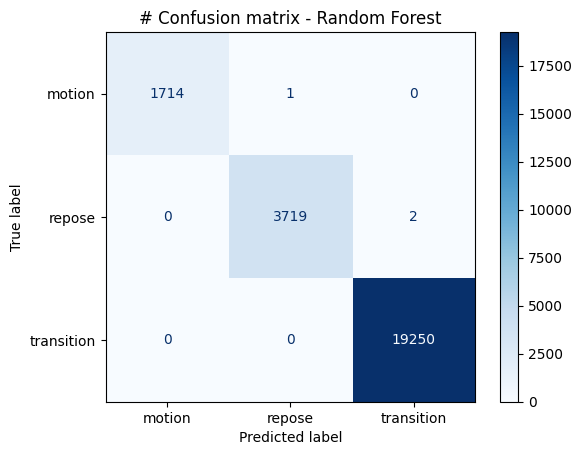

In [ ]:
# Accelerometer only
X = df[imu_cols_acc]
y = df['final_global_mobile_state']  # Label calculated by majority of percentiles

# Train-test division
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

print("Distribution in training:")
print(Counter(y_train))
print("\nTest distribution:")
print(Counter(y_test))

# Train Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
print("\nClassification report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("# Confusion matrix - Random Forest")
plt.show()

# Discussion

The process of extracting temporal features from the IMU data yielded statistically consistent results on the acceleration axes. However, the absence of relevant frequency peaks on all axes (peak_freq: 0.0000) reveals a technical limitation, possibly linked to the predominance of low-frequency components, highly stationary movements, and FFT parameters that are not optimal for capturing the dynamics of human movement. This result points to the need to review and adjust the window size, preprocessing, and sampling, as well as consider alternative techniques such as wavelet analysis to improve spectral sensitivity.

The visualizations, both the violin diagrams and the paired diagram, show differences in the central values ​​and acceleration variability between states, particularly on the z-axis. However, the significant overlap observed between states suggests that, while the percentile segmentation method achieves a rough differentiation, this procedure may not optimally capture more subtle transitions or activities, especially in less dynamic movements or limited datasets. The dominance of stable values ​​in acc_z may be associated with a fixed orientation or the gravitational influence on the sensor, an aspect to consider in the interpretation and design of future experiments.

The separation metrics obtained using the Fisher index and the distances between centroids quantify the discriminability between states. The modest Fisher values ​​and geometric distances suggest that, although statistically significant differences are achieved (ANOVA, p = 0.000000), these do not always translate into complete visual or practical separability in the feature space. This highlights the importance of combining univariate and multivariate analyses and validating the findings in more diverse scenarios with greater motor heterogeneity.

Finally, the outstanding performance of the Random Forest classifier (with global accuracy and a class of 1) should be interpreted with caution: it may be due to high class homogeneity, low complexity in the recorded movements, or even possible overfitting in controlled tasks. Consequently, it is recommended to validate these models with more varied datasets, such as adding gyroscope variables or combining them with UWB signals and in other environments, to certify their robustness and avoid overly optimistic conclusions derived from the current experiment, which was carried out exclusively as an academic exercise.

# conclusions

Statistical analysis of the IMU accelerometer signals allowed for the robust distinction of global movement states through percentile segmentation and temporal processing of the data. The metric results show quantifiable discriminability, especially in acc_y (Fisher's index of 0.5734), and very high statistical significance between groups (ANOVA, p = 0.000000 on all axes), demonstrating the viability of this approach in controlled experimental contexts. However, the frequency extraction methodology did not reveal relevant dynamic components, suggesting a need to explore alternative parameters and more advanced spectral techniques to capture a richer range of motor patterns.

While classification based solely on accelerometer characteristics achieved ideal performance in the Random Forest model (perfect accuracy, recovery, and F1 score, minimal confounding in the error matrix), this excellent performance should be interpreted with caution. The proposed method is hampered by the low diversity and limited range of movements included in the dataset, which can lead to overfitting and limit the generalizability of the results to other scenarios, subjects, or everyday activities. Thus, the methodology is promising but currently restricted to the specific conditions of the experiment.

Therefore, it is concluded that the approach using IMU accelerometry, percentile segmentation, and supervised models offers a robust framework for motor phase recognition, but requires methodological refinement for more complex and realistic applications. To strengthen the transfer of this methodology to practical monitoring or human interaction systems, it is recommended to integrate experiments with a wider range of movements and validate it in cross-modal and multimodal contexts.

# References

[1] F. Zafari et al., "A Survey of Indoor Localization Systems and Technologies," IEEE Communications Surveys & Tutorials, 2019.

[2] V. Barral et al., "NLOS Classification Based on RSS and Ranging Statistics Obtained from Low-Cost UWB Devices," 2019.

[3]I. Güvenç et al., "NLOS Identification and Weighted Least Squares Localization for UWB Systems," EURASIP Journal on Advances in Signal Processing, 2008.

[4] J. Khodjaev et al., "Survey of NLOS Identification and Error Mitigation Problems in UWB Positioning Algorithms," Annals of Telecommunications, 2010.

[5] H. Wymeersch et al., "A Machine Learning Approach to Ranging Error Mitigation for UWB Localization," IEEE Transactions on Communications, 2012.

[6] A. Ghio, S. Escalante, J. Tarrillo, “Analysis of Moving Average Filter for IMU Measurements on an 8-bit Microcontroller,” UTEC, Lima, Peru, 2018.   

[7] UTIAS Dynamic Systems Lab, "UTIL UWB Dataset," 2020. [Online]. Available: https://utiasdsl.github.io/util-uwb-dataset/.


